<a href="https://colab.research.google.com/github/PunyanuchChenya/AcademicoProject/blob/main/Project_code_ISOMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Function

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#sbert
from sentence_transformers import SentenceTransformer
#REDUSE
from sklearn.manifold import Isomap, SpectralEmbedding
#CLASSIFICATION
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
#distortion
from scipy.spatial.distance import pdist
#CROSS VALIDATION
from sklearn.model_selection import StratifiedKFold,cross_validate

#find neighbors component
import time #  บอกเวลาว่าใช้ไปเท่าไหร่
import itertools # เรียกใช้เพื่อทำ Loop


Dataset

In [ ]:
# dataset
df = pd.read_csv("/content/drive/MyDrive/all_news.csv")
# print(df)

#กำหนดชื่อ columns
texts = df["statement"].astype(str).tolist()
labels = df["label"].tolist()

#นับจำนวนข่าว
print("ข่าวทั้งหมด:", len(texts),
      "Fake:", sum(df['label']==False),
      "Real:", sum(df['label']==True))

ข่าวทั้งหมด: 4142 Fake: 2248 Real: 1894


# แปลง label

In [ ]:
# ตรวจสอบค่าเดิมก่อน (อาจจะเป็น True/False หรือ real/fake)
print("Original labels:", df['label'].unique())

# สร้างกฎการแปลงที่เหมาะสมกับข้อมูลของคุณ
# --- กรณีเป็น True/False ---
mapping_rule = {True: 0, False: 1}

# ทำการแปลงและทับข้อมูลในคอลัมน์เดิม
df['label'] = df['label'].map(mapping_rule)
print("Mapped labels:", df['label'].unique())

# แล้วจึงดึงข้อมูลที่แปลงเป็น 0/1 แล้วออกมาเป็น List
labels = df["label"].tolist()

Original labels: [ True False]
Mapped labels: [0 1]


In [ ]:
print("ค่าที่มีอยู่ในคอลัมน์ 'label' และจำนวนของแต่ละค่า:")
print(df['label'].value_counts())

ค่าที่มีอยู่ในคอลัมน์ 'label' และจำนวนของแต่ละค่า:
label
1    2248
0    1894
Name: count, dtype: int64


# SBERT

In [ ]:
#แปลงข้อความเป็น vector
model = SentenceTransformer("all-MiniLM-L6-v2")
x = model.encode(texts) #vectorเชิงความหมาย

#สร้าง dataframe
df_x = pd.DataFrame(x)
y = np.array(labels) #label
df_x.shape

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(4142, 384)



---



In [ ]:
cov_x = np.cov(df_x,rowvar = False ) # หา cov matrix
print(f'Covariance matrix {cov_x}')

covariance matrix [[ 2.75132194e-03 -5.10964615e-04  8.08732005e-05 ...  9.90858997e-05
   8.74277138e-05  1.49255740e-04]
 [-5.10964615e-04  2.74950384e-03 -1.21520635e-04 ...  8.77482358e-05
  -1.90401697e-04 -1.80836665e-04]
 [ 8.08732005e-05 -1.21520635e-04  2.12850045e-03 ... -8.99848408e-05
  -2.44755940e-04  3.04801630e-04]
 ...
 [ 9.90858997e-05  8.77482358e-05 -8.99848408e-05 ...  2.46408242e-03
   1.24557811e-04 -2.03301391e-04]
 [ 8.74277138e-05 -1.90401697e-04 -2.44755940e-04 ...  1.24557811e-04
   2.65892758e-03  1.27712825e-04]
 [ 1.49255740e-04 -1.80836665e-04  3.04801630e-04 ... -2.03301391e-04
   1.27712825e-04  1.59534727e-03]]


(array([  0.5,  21.5,  42.5,  63.5,  84.5, 105.5, 126.5, 147.5, 168.5,
        189.5, 210.5, 231.5, 252.5, 273.5, 294.5, 315.5, 336.5, 357.5,
        378.5]),
 [Text(0, 0.5, '0'),
  Text(0, 21.5, '21'),
  Text(0, 42.5, '42'),
  Text(0, 63.5, '63'),
  Text(0, 84.5, '84'),
  Text(0, 105.5, '105'),
  Text(0, 126.5, '126'),
  Text(0, 147.5, '147'),
  Text(0, 168.5, '168'),
  Text(0, 189.5, '189'),
  Text(0, 210.5, '210'),
  Text(0, 231.5, '231'),
  Text(0, 252.5, '252'),
  Text(0, 273.5, '273'),
  Text(0, 294.5, '294'),
  Text(0, 315.5, '315'),
  Text(0, 336.5, '336'),
  Text(0, 357.5, '357'),
  Text(0, 378.5, '378')])

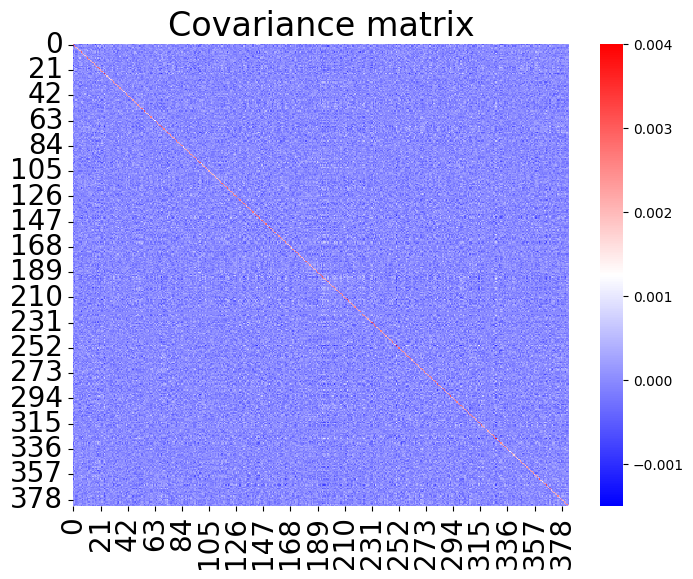

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6)) # ขนาดรูป

ax = sns.heatmap(cov_x, annot=False, cmap="bwr",
                 xticklabels=21, yticklabels=21,
                 vmin=-0.0015, vmax=0.004)

plt.title('Covariance matrix', fontsize=24)

# --- แก้ตรงนี้ (หมุน 90 องศา) ---
plt.xticks(fontsize=20, rotation=90)
plt.yticks(fontsize=20, rotation=0)
# -----------------------------


Axes(0.125,0.11;0.62x0.77)


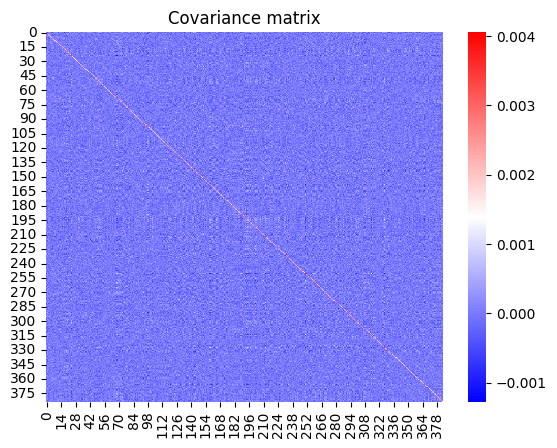

In [ ]:
# heatmap cov
heatmap = sns.heatmap(cov_x, annot=False, cmap="bwr")
print(heatmap)

# correlation

In [ ]:
# @title
cor_x = np.corrcoef(df_x,rowvar = False ) # หา corr matrix
print(f'Correlation matrix {cor_x}')
cor_x.shape

Correlation matrix [[ 1.         -0.18577743  0.03341928 ...  0.03805516  0.032324
   0.07124144]
 [-0.18577743  1.         -0.05023264 ...  0.03371193 -0.07041909
  -0.08634391]
 [ 0.03341928 -0.05023264  1.         ... -0.03929207 -0.10288288
   0.16540659]
 ...
 [ 0.03805516  0.03371193 -0.03929207 ...  1.          0.04866202
  -0.10253807]
 [ 0.032324   -0.07041909 -0.10288288 ...  0.04866202  1.
   0.06200884]
 [ 0.07124144 -0.08634391  0.16540659 ... -0.10253807  0.06200884
   1.        ]]


(384, 384)

(array([  0.5,  21.5,  42.5,  63.5,  84.5, 105.5, 126.5, 147.5, 168.5,
        189.5, 210.5, 231.5, 252.5, 273.5, 294.5, 315.5, 336.5, 357.5,
        378.5]),
 [Text(0, 0.5, '0'),
  Text(0, 21.5, '21'),
  Text(0, 42.5, '42'),
  Text(0, 63.5, '63'),
  Text(0, 84.5, '84'),
  Text(0, 105.5, '105'),
  Text(0, 126.5, '126'),
  Text(0, 147.5, '147'),
  Text(0, 168.5, '168'),
  Text(0, 189.5, '189'),
  Text(0, 210.5, '210'),
  Text(0, 231.5, '231'),
  Text(0, 252.5, '252'),
  Text(0, 273.5, '273'),
  Text(0, 294.5, '294'),
  Text(0, 315.5, '315'),
  Text(0, 336.5, '336'),
  Text(0, 357.5, '357'),
  Text(0, 378.5, '378')])

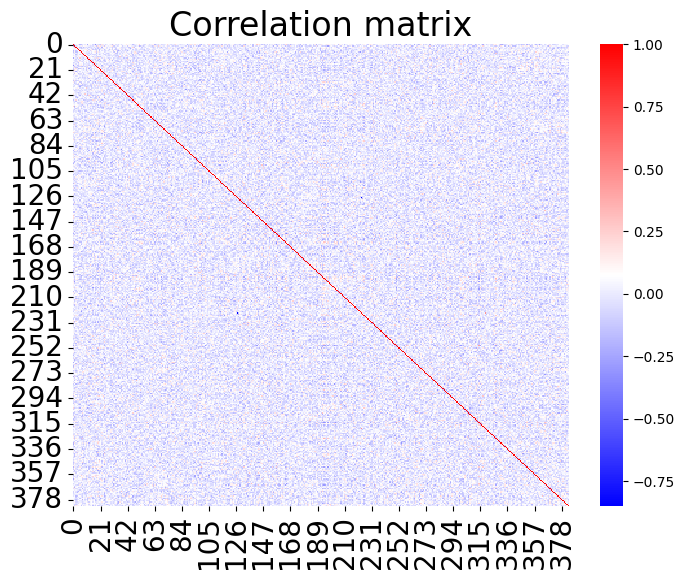

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# สมมติว่าคุณคำนวณ Correlation Matrix ไว้แล้ว (เช่น corr_matrix = df.corr())
# ถ้ายัง ให้คำนวณก่อน:
# corr_matrix = df_x.corr()

plt.figure(figsize=(8, 6)) # ขนาดรูปเท่าเดิม

# --- จุดที่เปลี่ยนสำหรับ Correlation ---
# vmin=-1, vmax=1 : คือค่ามาตรฐานของ Correlation
# (เพื่อให้สีขาวอยู่ตรงกลางที่เลข 0 พอดี สีแดงคือบวก สีน้ำเงินคือลบ)
ax = sns.heatmap(cor_x, annot=False, cmap="bwr",
                 xticklabels=21, yticklabels=21,
                  vmax=1)
# -----------------------------------

plt.title('Correlation matrix', fontsize=24) # แก้ชื่อหัวข้อ

# การจัดวางตัวเลขแกน (หมุน 90 องศาเหมือนเดิม)
plt.xticks(fontsize=20, rotation=90)
plt.yticks(fontsize=20, rotation=0)





---



NOTE เพื่อทำความเข้าใจ

n_jobs ทำงานอย่างไร
ลองนึกภาพว่าการสร้าง Random Forest (n_estimators=100) ต้นไม้ 100 ต้น

n_jobs=1 (ค่าเริ่มต้น): ใช้คน 1 คน สร้างต้นไม้ 100 ต้น

n_jobs=2: ใช้ 2 คน สร้างต้นไม้ 100 ต้น เสร็จเร็วขึ้น

n_jobs=-1: ใช้ทุกคนที่มี สร้างต้นไม้ 100 ต้น อันนี้เสร็จไวสุด

####NOTE



ถ้าเป้าหมายหลักคือ...	     // ความผิดพลาดที่รับไม่ได้คือ...	  //   Metric ที่ควรดูเป็นหลัก


ความแม่นยำในการชี้เป้า	    // กล่าวหาข่าวจริงว่าเป็นข่าวปลอม (False Positive)	// Precision, F0.5-Score


ความครอบคลุมในการตรวจจับ //	ปล่อยข่าวปลอมให้หลุดรอดไป (False Negative)	// Recall, F2-Score



ความสมดุล	// ทั้งสองอย่างสำคัญเท่ากัน	// F1-Score (มาตรฐาน)

#### F1 Macro: หนึ่งในวิธีแก้ปัญหา
F1 Macro คือวิธีการเฉลี่ยคะแนน F1 ของทุกคลาส แบบเท่าเทียมกัน โดยไม่สนใจว่าคลาสไหนมีข้อมูลเยอะหรือน้อย

วิธีการคือ:

หา F1 Score ของคลาส "การเมือง" (สมมติได้ 0.9)

หา F1 Score ของคลาส "กีฬา" (สมมติได้ 0.8)

หา F1 Score ของคลาส "บันเทิง" (สมมติได้ 0.7)

นำคะแนนทั้งหมดมาบวกกันแล้วหารด้วยจำนวนคลาส: (0.9 + 0.8 + 0.7) / 3 = 0.8

ดังนั้น F1 Macro Score ของโมเดลนี้คือ 0.8

สรุป: F1 Score คือตัวชี้วัด ส่วน F1 Macro คือวิธีการหาค่าเฉลี่ยของตัวชี้วัดนั้นในกรณีที่มีหลายคลาสนั่นเองครับ

#standarddize

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
means = np.mean(df_x, axis=0)
variances = np.var(df_x, axis=0)
dimensions = np.arange(1,len(means)+1)

result_df = pd.DataFrame({
    'มิติที่': dimensions,
    'ค่าเฉลี่ย': means,
    'ความแปรปรวน': variances
})

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(result_df)

print(f"\n\nค่าเฉลี่ยสูงสุด : {np.max(means):.6f}")
print(f"ค่าเฉลี่ยต่ำสุด : {np.min(means):.6f}")
print(f"ค่าเฉลี่ยรวม : :{np.mean(means):.6f}")

print(f"ความแปรปรวนสูงสุด : {np.max(variances):.6f}")
print(f"ความแปรปรวนต่ำสุด : {np.min(variances):.6f}")
print(f"ความแปรปรวนเฉลี่ย : {np.mean(variances):.6f}")

     มิติที่     ค่าเฉลี่ย   ความแปรปรวน
0          1  1.649827e-02  2.750656e-03
1          2  6.354412e-03  2.748838e-03
2          3  1.141568e-02  2.127985e-03
3          4  1.268768e-02  1.795725e-03
4          5  1.575310e-03  2.252149e-03
5          6  1.043029e-02  1.946362e-03
6          7 -5.095637e-03  3.007407e-03
7          8 -1.755122e-02  2.291837e-03
8          9 -2.613895e-02  1.921879e-03
9         10  1.199922e-02  1.831683e-03
10        11  1.362235e-02  2.208479e-03
11        12  4.604961e-02  2.804464e-03
12        13  9.123784e-03  2.256036e-03
13        14 -1.717272e-02  1.964042e-03
14        15 -1.426047e-02  2.092231e-03
15        16  1.868848e-02  2.152673e-03
16        17  2.892287e-03  2.187950e-03
17        18 -1.515119e-02  2.476426e-03
18        19 -6.135425e-03  2.069787e-03
19        20  1.737299e-02  2.882108e-03
20        21  8.046625e-03  3.241579e-03
21        22  1.124575e-02  2.158617e-03
22        23  1.788184e-02  2.604170e-03
23        24  1.

In [ ]:
scaler = StandardScaler()
df_x_sc = scaler.fit_transform(df_x)

In [ ]:
means = np.mean(df_x_sc, axis=0)
variances = np.var(df_x_sc, axis=0)
dimensions = np.arange(1,len(means)+1)

result_df = pd.DataFrame({
    'มิติที่': dimensions,
    'ค่าเฉลี่ย': means,
    'ความแปรปรวน': variances
})

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(result_df)

print(f"\n\nค่าเฉลี่ยสูงสุด : {np.max(means):.6f}")
print(f"ค่าเฉลี่ยต่ำสุด : {np.min(means):.6f}")
print(f"ค่าเฉลี่ยรวม : :{np.mean(means):.6f}")

print(f"ความแปรปรวนสูงสุด : {np.max(variances):.6f}")
print(f"ความแปรปรวนต่ำสุด : {np.min(variances):.6f}")
print(f"ความแปรปรวนเฉลี่ย : {np.mean(variances):.6f}")

     มิติที่     ค่าเฉลี่ย  ความแปรปรวน
0          1 -1.721081e-08     1.000000
1          2  9.848725e-08     1.000001
2          3 -1.093663e-08     1.000001
3          4  7.554911e-10     1.000000
4          5 -3.879986e-09     0.999997
5          6 -2.614718e-08     0.999999
6          7  9.065892e-09     1.000000
7          8 -5.745330e-09     1.000000
8          9  7.655642e-09     1.000001
9         10  1.102297e-08     1.000000
10        11  3.337831e-08     1.000000
11        12 -2.499776e-08     0.999999
12        13 -4.722898e-08     1.000000
13        14 -4.907094e-09     0.999999
14        15 -9.986872e-09     1.000001
15        16 -2.489523e-09     0.999998
16        17  4.669654e-09     0.999999
17        18 -2.132643e-08     1.000001
18        19  5.561853e-09     1.000000
19        20 -3.486771e-08     1.000000
20        21  1.151224e-10     1.000000
21        22  3.352941e-09     0.999998
22        23 -3.257965e-08     1.000000
23        24 -4.662459e-09     1.000000


#LOOP

In [ ]:
# @title
# เมตริกที่ต้องการวัดผล
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

print(f"ขนาดข้อมูลเริ่มต้น: {x.shape}")
print("-" * 40)


# --- กำหนดค่าพารามิเตอร์ที่ต้องการทดลอง ---
# คุณสามารถเพิ่มหรือเปลี่ยนค่าใน list เหล่านี้ได้ตามต้องการ
n_neighbors_list = [5,45,85,125,165]
n_components_list = [50, 100, 150, 200,227]

# สร้าง list ว่างสำหรับเก็บผลลัพธ์ของแต่ละรอบ
results_list = []


# --- เริ่มการวนลูปเพื่อทดลองพารามิเตอร์ ---
for n_neighbors in n_neighbors_list:
    for n_components in n_components_list:
        print(f"\n===== กำลังทดลอง: Neighbors = {n_neighbors}, Components = {n_components} =====")

        # --- สร้างโมเดล SpectralEmbedding ---
        ISOMAP_model = Isomap(
            n_components=n_components,
            n_neighbors=n_neighbors,
            n_jobs=1
        )

        # ทำการลดมิติข้อมูล
        X_ISOMAP = ISOMAP_model.fit_transform(df_x_sc)
        print(f"ขนาดข้อมูลหลังลดมิติ: {X_ISOMAP.shape}")

        # --- วัดค่า Distortion ---
        dist_original = pdist(x)
        dist_reduced = pdist(X_ISOMAP)
        numerator = np.sum((dist_original - dist_reduced)**2)
        denominator = np.sum(dist_original**2)
        stress_value = np.sqrt(numerator / denominator)
        print(f"Normalized Stress: {stress_value:.4f}")

        # --- สร้างโมเดล Random Forest และประเมินผล ---
        model_RANDOM = RandomForestClassifier(n_estimators=200,
                        max_depth=10,
                        min_samples_split=2, random_state=42, n_jobs=1)

        cv_results_ISOMAP = cross_validate(
            estimator=model_RANDOM,
            X=X_ISOMAP,
            y=y,
            cv=5,
            scoring=scoring_metrics
        )

        # --- เก็บผลลัพธ์ลงใน Dictionary ---
        current_result = {
            'n_neighbors': n_neighbors,
            'n_components': n_components,
            'stress': stress_value,
            'fit_time': cv_results_ISOMAP['fit_time'].mean(),
            'score_time': cv_results_ISOMAP['score_time'].mean(),
            'accuracy': cv_results_ISOMAP['test_accuracy'].mean(),
            'precision': cv_results_ISOMAP['test_precision_macro'].mean(),
            'recall': cv_results_ISOMAP['test_recall_macro'].mean(),
            'f1_score': cv_results_ISOMAP['test_f1_macro'].mean()
        }

        # เพิ่ม dictionary ของรอบนี้เข้าไปใน list กลาง
        results_list.append(current_result)
        print("-" * 40)


# --- 4. สรุปผลลัพธ์ทั้งหมด ---
print("\n\n--- สรุปผลการทดลองทั้งหมด ---")

# แปลง list ของผลลัพธ์เป็น Pandas DataFrame เพื่อให้ดูสวยงาม
results_df = pd.DataFrame(results_list)

# จัดเรียงตารางตาม f1-score จากมากไปน้อย
results_df = results_df.sort_values(by='f1_score', ascending=False).reset_index(drop=True)

print(results_df)


# --- 5. แสดงผลลัพธ์ที่ดีที่สุด ---
best_result = results_df.iloc[0] # แถวแรกคือผลที่ดีที่สุด
print("\n--- ผลลัพธ์ที่ดีที่สุด (วัดจาก F1-Score) ---")
print(f"จำนวน Neighbors (n_neighbors): {best_result['n_neighbors']}")
print(f"จำนวน Components (n_components): {best_result['n_components']}")
print(f"F1-Score: {best_result['f1_score']:.4f}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"Normalized Stress: {best_result['stress']:.4f}")

ขนาดข้อมูลเริ่มต้น: (4142, 384)
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 50 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 50)
Normalized Stress: 96.9996
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 100 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 100)
Normalized Stress: 111.9773
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 150 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 150)
Normalized Stress: 119.8780
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 200 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 200)
Normalized Stress: 125.2191
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 227 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 227)
Normalized Stress: 127.6084
----------------------------------------

===== กำลังทดลอง: Neighbors = 45, Components = 50 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 50)
Normalized Stress: 51.2181
-------------

In [ ]:
# @title
# --- สรุปผลลัพธ์ทั้งหมด ---
print("\n\n--- สรุปผลการทดลองทั้งหมด ---")

# แปลง list ของผลลัพธ์เป็น Pandas DataFrame เพื่อให้ดูสวยงาม
results_df = pd.DataFrame(results_list)

print(results_df)



--- สรุปผลการทดลองทั้งหมด ---
    n_neighbors  n_components      stress   fit_time  score_time  accuracy  \
0             5            50   96.999574   6.676991    0.048818  0.611537   
1             5           100  111.977341   8.382982    0.044834  0.603572   
2             5           150  119.878045   9.898955    0.043285  0.596570   
3             5           200  125.219098  11.566973    0.051081  0.596332   
4             5           227  127.608443  12.116133    0.051076  0.592947   
5            45            50   51.218089   5.814594    0.040061  0.608164   
6            45           100   59.085890   8.120239    0.050977  0.605266   
7            45           150   64.234665   9.809202    0.044810  0.603331   
8            45           200   68.279779  11.226943    0.044985  0.605266   
9            45           227   70.184435  12.004440    0.054220  0.602364   
10           85            50   47.012283   5.828797    0.041805  0.616612   
11           85           100   

In [ ]:
# @title

# 1. กำหนดตำแหน่งและชื่อไฟล์ในโฟลเดอร์ 'PROJECT FILE'
drive_file_path = '/content/drive/MyDrive/PROJECTFILE/ISOMAP_tuning_results12.xlsx'

# 2. ใช้คำสั่ง .to_excel() เพื่อบันทึกไปยังตำแหน่งที่กำหนดไว้
results_df.to_excel(
    drive_file_path,
    sheet_name='Tuning_Results',
    index=False
)

print(f"\n✅ บันทึกข้อมูลลงใน Google Drive ที่ '{drive_file_path}' เรียบร้อยแล้วครับ")


✅ บันทึกข้อมูลลงใน Google Drive ที่ '/content/drive/MyDrive/PROJECTFILE/ISOMAP_tuning_results12.xlsx' เรียบร้อยแล้วครับ


#LOOP ISOMAP&RF

In [ ]:
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

print(f"ขนาดข้อมูลเริ่มต้น: {df_x_sc.shape}")
print("-" * 50)


# --- กำหนดค่าพารามิเตอร์ที่ต้องการทดลอง ---
# Spectral Embedding params
n_neighbors_list = [5,45,85,125,165]
n_components_list = [50, 100, 150, 200,227]
# RandomForest params
max_depth_list = [2,5,10]
n_estimators_list = [100,200,300]
min_samples_split_list = [2, 5,10]

# สร้าง list ว่างสำหรับเก็บผลลัพธ์
results_list = []
start_time = time.time()

# --- เริ่มการวนลูปเพื่อทดลองพารามิเตอร์ ---
for n_neighbors in n_neighbors_list:
    for n_components in n_components_list:
        print(f"\n===== ISOMAP: Neighbors={n_neighbors}, Components={n_components} =====")

        # ลดมิติข้อมูล (ทำครั้งเดียวก่อน Loop ของ RF)
        ISOMAP_model = Isomap(
            n_components=n_components, n_neighbors=n_neighbors,
            n_jobs=1
        )
        X_ISOMAP = ISOMAP_model.fit_transform(df_x_sc)

        dist_original = pdist(df_x_sc)
        dist_reduced = pdist(X_ISOMAP)
        stress_value = np.sqrt(np.sum((dist_original - dist_reduced)**2) / np.sum(dist_original**2))

        # *** เริ่ม Loop สำหรับพารามิเตอร์ของ RandomForest ***
        for max_depth in max_depth_list:
            for n_estimators in n_estimators_list:
                for min_samples_split in min_samples_split_list:
                    print(f"--- Testing RF: max_depth={max_depth}, n_estimators={n_estimators}, min_samples_split={min_samples_split} ---")

                    model_RANDOM = RandomForestClassifier(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        min_samples_split=min_samples_split,
                        random_state=42,
                        n_jobs=1
                    )

                    cv_results_ISOMAP = cross_validate(
                        estimator=model_RANDOM, X=X_ISOMAP, y=y,
                        cv=5, scoring=scoring_metrics
                    )

                    current_result = {
                        'n_neighbors': n_neighbors,
                        'n_components': n_components,
                        'max_depth': max_depth,
                        'n_estimators': n_estimators,
                        'min_samples_split': min_samples_split,
                        'stress': stress_value,
                        'fit_time': cv_results_ISOMAP['fit_time'].mean(),
                        'score_time': cv_results_ISOMAP['score_time'].mean(),
                        'accuracy': cv_results_ISOMAP['test_accuracy'].mean(),
                        'precision': cv_results_ISOMAP['test_precision_macro'].mean(),
                        'recall': cv_results_ISOMAP['test_recall_macro'].mean(),
                        'f1_score': cv_results_ISOMAP['test_f1_macro'].mean()
                    }
                    results_list.append(current_result)
        print("-" * 50)

end_time = time.time()
print(f"\n\nใช้เวลาประมวลผลทั้งหมด: {end_time - start_time:.2f} วินาที")
results_df_rf = pd.DataFrame(results_list)

ขนาดข้อมูลเริ่มต้น: (4142, 384)
--------------------------------------------------

===== ISOMAP: Neighbors=5, Components=50 =====
--- Testing RF: max_depth=2, n_estimators=100, min_samples_split=2 ---
--- Testing RF: max_depth=2, n_estimators=100, min_samples_split=5 ---
--- Testing RF: max_depth=2, n_estimators=100, min_samples_split=10 ---
--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=2 ---
--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=5 ---
--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=10 ---
--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=2 ---
--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=5 ---
--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=10 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=2 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=5 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=10 ---
--- Testing R

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=5 ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=10 ---


...

--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=5 ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=10 ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=2 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=5 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=10 ---
--- Testing RF: max_depth=5, n_estimators=200, min_samples_split=2 ---
--- Testing RF: max_depth=5, n_estimators=200, min_samples_split=5 ---
--- Testing RF: max_depth=5, n_estimators=200, min_samples_split=10 ---
--- Testing RF: max_depth=5, n_estimators=300, min_samples_split=2 ---
--- Testing RF: max_depth=5, n_estimators=300, min_samples_split=5 ---
--- Testing RF: max_depth=5, n_estimators=300, min_samples_split=10 ---
--- Testing RF: max_depth=10, n_estimators=100, min_samples_split=2 ---
--- Testing RF: max_depth=10, n_estimators=100, min_samples_split=5 ---
--- Testing RF: max_depth=10, n_estimators=100, min_samples_split=10 ---
--- Testing RF: max_depth=10, n_estimators=200, min_samples_split=2 ---
--- Testing RF: max_depth=10, n_estimators=200, min_samples_split=5 -

In [ ]:
# @title
# --- สรุปผลลัพธ์ทั้งหมด ---
# print("\n\n--- สรุปผลการทดลองทั้งหมด ---")

# # แปลง list ของผลลัพธ์เป็น Pandas DataFrame เพื่อให้ดูสวยงาม
# results_df_rf = pd.DataFrame(results_list)

# print(results_df)



--- สรุปผลการทดลองทั้งหมด ---
    n_neighbors  n_components      stress   fit_time  score_time  accuracy  \
0             5            50   96.999574   6.676991    0.048818  0.611537   
1             5           100  111.977341   8.382982    0.044834  0.603572   
2             5           150  119.878045   9.898955    0.043285  0.596570   
3             5           200  125.219098  11.566973    0.051081  0.596332   
4             5           227  127.608443  12.116133    0.051076  0.592947   
5            45            50   51.218089   5.814594    0.040061  0.608164   
6            45           100   59.085890   8.120239    0.050977  0.605266   
7            45           150   64.234665   9.809202    0.044810  0.603331   
8            45           200   68.279779  11.226943    0.044985  0.605266   
9            45           227   70.184435  12.004440    0.054220  0.602364   
10           85            50   47.012283   5.828797    0.041805  0.616612   
11           85           100   

In [ ]:
# @title

# 1. กำหนดตำแหน่งและชื่อไฟล์ในโฟลเดอร์ 'PROJECT FILE'
drive_file_path = '/content/drive/MyDrive/PROJECTFILE/ISOMAP_tuning_results_rf13.xlsx'

# 2. ใช้คำสั่ง .to_excel() เพื่อบันทึกไปยังตำแหน่งที่กำหนดไว้
results_df_rf.to_excel(
    drive_file_path,
    sheet_name='Tuning_Results',
    index=False
)

print(f"\n✅ บันทึกข้อมูลลงใน Google Drive ที่ '{drive_file_path}' เรียบร้อยแล้วครับ")


✅ บันทึกข้อมูลลงใน Google Drive ที่ '/content/drive/MyDrive/PROJECTFILE/ISOMAP_tuning_results_rf13.xlsx' เรียบร้อยแล้วครับ


#เปรียบเทียบ

##ก่อนลด

In [ ]:
# @title
#สร้าง model ให้เดียวกับ rf ที่ดีที่สุดใน laplacian
model_baseline = RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=2, random_state=42,n_jobs=1)

In [ ]:
# @title
# --- กำหนดเมตริกที่ต้องการวัดผล ---
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# --- เรียกใช้ cross_validate ---
# เพื่อให้ข้อมูลถูกแบ่งแบบเดิมเป๊ะๆ ทุกครั้ง ใช้ StratifiedKFold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# @title
# cross_validate จะคืนค่าเป็น dictionary ที่มีข้อมูลการทำงานและคะแนนทั้งหมด
cv_results = cross_validate(
    estimator=model_baseline,
    X=x,
    y=y,
    cv=5,
    scoring=scoring_metrics
)

In [ ]:
# @title
# --- แสดงผลลัพธ์ ---
print("\n--- ผลลัพธ์การประเมินผล ก่อนลดมิติ ---")
print(f"ระยะเวลาในการฝึก (Fit Time): {cv_results['fit_time'].mean():.2f} วินาที")
print(f"ระยะเวลาในการทดสอบ (Score Time): {cv_results['score_time'].mean():.2f} วินาที")
print("-" * 30)

# แสดงค่าเฉลี่ยและค่าเบี่ยงเบนมาตรฐานของแต่ละเมตริก
mean_accuracy = cv_results['test_accuracy'].mean()
std_accuracy = cv_results['test_accuracy'].std()
print(f"Accuracy: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")

mean_precision = cv_results['test_precision_macro'].mean()
std_precision = cv_results['test_precision_macro'].std()
print(f"Precision: {mean_precision:.4f} (+/- {std_precision:.4f})")

mean_recall = cv_results['test_recall_macro'].mean()
std_recall = cv_results['test_recall_macro'].std()
print(f"Recall: {mean_recall:.4f} (+/- {std_recall:.4f})")

mean_f1 = cv_results['test_f1_macro'].mean()
std_f1 = cv_results['test_f1_macro'].std()
print(f"F1-Score: {mean_f1:.4f} (+/- {std_f1:.4f})")


--- ผลลัพธ์การประเมินผล ก่อนลดมิติ ---
ระยะเวลาในการฝึก (Fit Time): 10.64 วินาที
ระยะเวลาในการทดสอบ (Score Time): 0.03 วินาที
------------------------------
Accuracy: 0.6108 (+/- 0.0133)
Precision: 0.6148 (+/- 0.0171)
Recall: 0.5924 (+/- 0.0132)
F1-Score: 0.5811 (+/- 0.0139)


##หลังลด

In [ ]:
best_n_components = 50
best_n_neighbors = 180

In [ ]:
# @title
# --- สร้างโมเดล ---
print(f"ขนาดข้อมูลเริ่มต้น: {x.shape}")
final_isomap_model = Isomap(
    n_components=best_n_components,
    n_neighbors=best_n_neighbors
)
X_isomap = final_isomap_model.fit_transform(x)
print(f"ขนาดข้อมูลใหม่: {X_isomap.shape}")

# ตอนนี้ 'X_isomap' คือข้อมูลใหม่ที่พร้อมนำไปใช้กับ Random Forest

ขนาดข้อมูลเริ่มต้น: (4142, 384)
ขนาดข้อมูลใหม่: (4142, 50)


In [ ]:
# --- สร้างโมเดล ---
model_RANDOM = RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=2, random_state=42,n_jobs=1)

In [ ]:
# @title
# cv_strategy อยู่ตรงยังไม่ลด
# cross_validate จะคืนค่าเป็น dictionary ที่มีข้อมูลการทำงานและคะแนนทั้งหมด
cv_results_ISOMAP = cross_validate(
    estimator=model_RANDOM,
    X=X_isomap,
    y=y,
    cv=5,
    scoring=scoring_metrics
)

In [ ]:
# @title
# --- แสดงผลลัพธ์ ---
print("\n--- ผลลัพธ์การประเมินผล หลังลดมิติ ---")
print(f"ระยะเวลาในการฝึก (Fit Time): {cv_results_ISOMAP['fit_time'].mean():.2f} วินาที")
print(f"ระยะเวลาในการทดสอบ (Score Time): {cv_results_ISOMAP['score_time'].mean():.2f} วินาที")
print("-" * 30)

# แสดงค่าเฉลี่ยและค่าเบี่ยงเบนมาตรฐานของแต่ละเมตริก
mean_accuracy_ISOMAP = cv_results_ISOMAP['test_accuracy'].mean()
std_accuracy_ISOMAP = cv_results_ISOMAP['test_accuracy'].std()
print(f"Accuracy (ISOMAP): {mean_accuracy_ISOMAP:.4f} (+/- {std_accuracy_ISOMAP:.4f})")

mean_precision_ISOMAP = cv_results_ISOMAP['test_precision_macro'].mean()
std_precision_ISOMAP = cv_results_ISOMAP['test_precision_macro'].std()
print(f"Precision (ISOMAP): {mean_precision_ISOMAP:.4f} (+/- {std_precision_ISOMAP:.4f})")

mean_recall_ISOMAP = cv_results_ISOMAP['test_recall_macro'].mean()
std_recall_ISOMAP = cv_results_ISOMAP['test_recall_macro'].std()
print(f"Recall (ISOMAP): {mean_recall_ISOMAP:.4f} (+/- {std_recall_ISOMAP:.4f})")

mean_f1_ISOMAP = cv_results_ISOMAP['test_f1_macro'].mean()
std_f1_ISOMAP = cv_results_ISOMAP['test_f1_macro'].std()
print(f"F1-Score (ISOMAP): {mean_f1_ISOMAP:.4f} (+/- {std_f1_ISOMAP:.4f})")


--- ผลลัพธ์การประเมินผล หลังลดมิติ ---
ระยะเวลาในการฝึก (Fit Time): 3.94 วินาที
ระยะเวลาในการทดสอบ (Score Time): 0.03 วินาที
------------------------------
Accuracy (ISOMAP): 0.6188 (+/- 0.0124)
Precision (ISOMAP): 0.6195 (+/- 0.0136)
Recall (ISOMAP): 0.6035 (+/- 0.0131)
F1-Score (ISOMAP): 0.5973 (+/- 0.0146)


In [ ]:
# @title
comparison_data_ISOMAP = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Fit Time (s)', 'Score Time (s)'],
    'Before ISOMAP (Mean)': [mean_accuracy, mean_precision, mean_recall, mean_f1, cv_results['fit_time'].mean(), cv_results['score_time'].mean()],
    'Before ISOMAP (Std)': [std_accuracy, std_precision, std_recall, std_f1, cv_results['fit_time'].std(), cv_results['score_time'].std()],
    'After ISOMAP (Mean)': [mean_accuracy_ISOMAP, mean_precision_ISOMAP, mean_recall_ISOMAP, mean_f1_ISOMAP, cv_results_ISOMAP['fit_time'].mean(), cv_results_ISOMAP['score_time'].mean()],
    'After ISOMAP (Std)': [std_accuracy_ISOMAP, std_precision_ISOMAP, std_recall_ISOMAP, std_f1_ISOMAP, cv_results_ISOMAP['fit_time'].std(), cv_results_ISOMAP['score_time'].std()]
}

comparison_df_ISOMAP = pd.DataFrame(comparison_data_ISOMAP)

# แสดงตารางเปรียบเทียบ
print("--- ตารางเปรียบเทียบผลลัพธ์การจัดประเภท ก่อนและหลังลดมิติด้วย ISOMAP ---")
display(comparison_df_ISOMAP)

if mean_accuracy_ISOMAP > mean_accuracy:
    print("Accuracy หลังลดมิติด้วย ISOMAP สูงกว่าก่อนลดมิติ")
elif mean_accuracy_ISOMAP < mean_accuracy:
    print("Accuracy หลังลดมิติด้วย ISOMAP ต่ำกว่าก่อนลดมิติ")
else:
    print("Accuracy หลังและก่อนลดมิติด้วย ISOMAP เท่ากัน")

if cv_results_ISOMAP['fit_time'].mean() < cv_results['fit_time'].mean():
    print(f"ใช้เวลาในการฝึก (Fit Time) หลังลดมิติด้วย ISOMAP น้อยกว่า ({cv_results_ISOMAP['fit_time'].mean():.2f}s < {cv_results['fit_time'].mean():.2f}s)")
elif cv_results_ISOMAP['fit_time'].mean() > cv_results['fit_time'].mean():
     print(f"ใช้เวลาในการฝึก (Fit Time) หลังลดมิติด้วย ISOMAP มากกว่า ({cv_results_ISOMAP['fit_time'].mean():.2f}s > {cv_results['fit_time'].mean():.2f}s)")
else:
    print("ใช้เวลาในการฝึก (Fit Time) หลังและก่อนลดมิติด้วย ISOMAP เท่ากัน")

--- ตารางเปรียบเทียบผลลัพธ์การจัดประเภท ก่อนและหลังลดมิติด้วย ISOMAP ---


,Metric,Before ISOMAP (Mean),Before ISOMAP (Std),After ISOMAP (Mean),After ISOMAP (Std)
0,Accuracy,0.610819,0.013341,0.618776,0.012390
1,Precision,0.614801,0.017074,0.619520,0.013628
2,Recall,0.592402,0.013213,0.603478,0.013099
3,F1-Score,0.581118,0.013909,0.597258,0.014588
4,Fit Time (s),10.641431,0.607859,3.943082,0.213999
5,Score Time (s),0.030382,0.000713,0.028706,0.001672


Accuracy หลังลดมิติด้วย ISOMAP สูงกว่าก่อนลดมิติ
ใช้เวลาในการฝึก (Fit Time) หลังลดมิติด้วย ISOMAP น้อยกว่า (3.94s < 10.64s)


# LOOP no STANSARDIZE

## LOOP

In [ ]:
# @title
# เมตริกที่ต้องการวัดผล
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

print(f"ขนาดข้อมูลเริ่มต้น: {x.shape}")
print("-" * 40)


# --- กำหนดค่าพารามิเตอร์ที่ต้องการทดลอง ---
# คุณสามารถเพิ่มหรือเปลี่ยนค่าใน list เหล่านี้ได้ตามต้องการ
n_neighbors_list = [5,45,85,125,165]
n_components_list = [50, 100, 150, 200,227]

# สร้าง list ว่างสำหรับเก็บผลลัพธ์ของแต่ละรอบ
results_list = []


# --- เริ่มการวนลูปเพื่อทดลองพารามิเตอร์ ---
for n_neighbors in n_neighbors_list:
    for n_components in n_components_list:
        print(f"\n===== กำลังทดลอง: Neighbors = {n_neighbors}, Components = {n_components} =====")

        # --- สร้างโมเดล SpectralEmbedding ---
        ISOMAP_model = Isomap(
            n_components=n_components,
            n_neighbors=n_neighbors,
            n_jobs=1
        )

        # ทำการลดมิติข้อมูล
        X_ISOMAP = ISOMAP_model.fit_transform(df_x)
        print(f"ขนาดข้อมูลหลังลดมิติ: {X_ISOMAP.shape}")

        # --- วัดค่า Distortion ---
        dist_original = pdist(x)
        dist_reduced = pdist(X_ISOMAP)
        numerator = np.sum((dist_original - dist_reduced)**2)
        denominator = np.sum(dist_original**2)
        stress_value = np.sqrt(numerator / denominator)
        print(f"Normalized Stress: {stress_value:.4f}")

        # --- สร้างโมเดล Random Forest และประเมินผล ---
        model_RANDOM = RandomForestClassifier(n_estimators=200,
                        max_depth=10,
                        min_samples_split=2, random_state=42, n_jobs=1)

        cv_results_ISOMAP = cross_validate(
            estimator=model_RANDOM,
            X=X_ISOMAP,
            y=y,
            cv=5,
            scoring=scoring_metrics
        )

        # --- เก็บผลลัพธ์ลงใน Dictionary ---
        current_result = {
            'n_neighbors': n_neighbors,
            'n_components': n_components,
            'stress': stress_value,
            'fit_time': cv_results_ISOMAP['fit_time'].mean(),
            'score_time': cv_results_ISOMAP['score_time'].mean(),
            'accuracy': cv_results_ISOMAP['test_accuracy'].mean(),
            'precision': cv_results_ISOMAP['test_precision_macro'].mean(),
            'recall': cv_results_ISOMAP['test_recall_macro'].mean(),
            'f1_score': cv_results_ISOMAP['test_f1_macro'].mean()
        }

        # เพิ่ม dictionary ของรอบนี้เข้าไปใน list กลาง
        results_list.append(current_result)
        print("-" * 40)


# --- 4. สรุปผลลัพธ์ทั้งหมด ---
print("\n\n--- สรุปผลการทดลองทั้งหมด ---")

# แปลง list ของผลลัพธ์เป็น Pandas DataFrame เพื่อให้ดูสวยงาม
results_dfnostd = pd.DataFrame(results_list)

# จัดเรียงตารางตาม f1-score จากมากไปน้อย
results_dfnostd = results_df.sort_values(by='f1_score', ascending=False).reset_index(drop=True)


ขนาดข้อมูลเริ่มต้น: (4142, 384)
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 50 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 50)
Normalized Stress: 3.6963
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 100 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 100)
Normalized Stress: 4.4149
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 150 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 150)
Normalized Stress: 4.7945
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 200 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 200)
Normalized Stress: 5.0514
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 227 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 227)
Normalized Stress: 5.1659
----------------------------------------

===== กำลังทดลอง: Neighbors = 45, Components = 50 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 50)
Normalized Stress: 1.5057
-----------------------

In [ ]:
# @title

# 1. กำหนดตำแหน่งและชื่อไฟล์ในโฟลเดอร์ 'PROJECT FILE'
drive_file_path = '/content/drive/MyDrive/PROJECTFILE/ISOMAP_tuning_resultsnostd1.xlsx'

# 2. ใช้คำสั่ง .to_excel() เพื่อบันทึกไปยังตำแหน่งที่กำหนดไว้
results_dfnostd.to_excel(
    drive_file_path,
    sheet_name='Tuning_Results',
    index=False
)

print(f"\n✅ บันทึกข้อมูลลงใน Google Drive ที่ '{drive_file_path}' เรียบร้อยแล้วครับ")


✅ บันทึกข้อมูลลงใน Google Drive ที่ '/content/drive/MyDrive/PROJECTFILE/ISOMAP_tuning_resultsnostd1.xlsx' เรียบร้อยแล้วครับ


##LOOP rf

In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.manifold import SpectralEmbedding
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist
import time


scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"ขนาดข้อมูลเริ่มต้น: {x.shape}")
print("-" * 50)


# --- กำหนดค่าพารามิเตอร์ที่ต้องการทดลอง ---
# Spectral Embedding params
n_neighbors_list = [5,45,85,125,165]
n_components_list = [50, 100, 150, 200,227]
# RandomForest params
max_depth_list = [2,5,10]
n_estimators_list = [100,200,300]
min_samples_split_list = [2, 5,10]

# สร้าง list ว่างสำหรับเก็บผลลัพธ์
results_list = []
start_time = time.time()

# --- เริ่มการวนลูปเพื่อทดลองพารามิเตอร์ ---
for n_neighbors in n_neighbors_list:
    for n_components in n_components_list:
        print(f"\n===== ISOMAP: Neighbors={n_neighbors}, Components={n_components} =====")

        # ลดมิติข้อมูล (ทำครั้งเดียวก่อน Loop ของ RF)
        ISOMAP_model = Isomap(
            n_components=n_components, n_neighbors=n_neighbors,
            n_jobs=1
        )
        X_ISOMAP = ISOMAP_model.fit_transform(df_x)

        dist_original = pdist(x)
        dist_reduced = pdist(X_ISOMAP)
        stress_value = np.sqrt(np.sum((dist_original - dist_reduced)**2) / np.sum(dist_original**2))

        # *** เริ่ม Loop สำหรับพารามิเตอร์ของ RandomForest ***
        for max_depth in max_depth_list:
            for n_estimators in n_estimators_list:
                for min_samples_split in min_samples_split_list:
                    print(f"--- Testing RF: max_depth={max_depth}, n_estimators={n_estimators}, min_samples_split={min_samples_split} ---")

                    model_RANDOM = RandomForestClassifier(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        min_samples_split=min_samples_split,
                        random_state=42,
                        n_jobs=1
                    )

                    cv_results_ISOMAP = cross_validate(
                        estimator=model_RANDOM, X=X_ISOMAP, y=y,
                        cv=5, scoring=scoring_metrics
                    )

                    current_result = {
                        'n_neighbors': n_neighbors,
                        'n_components': n_components,
                        'max_depth': max_depth,
                        'n_estimators': n_estimators,
                        'min_samples_split': min_samples_split,
                        'stress': stress_value,
                        'fit_time': cv_results_ISOMAP['fit_time'].mean(),
                        'score_time': cv_results_ISOMAP['score_time'].mean(),
                        'accuracy': cv_results_ISOMAP['test_accuracy'].mean(),
                        'precision': cv_results_ISOMAP['test_precision_macro'].mean(),
                        'recall': cv_results_ISOMAP['test_recall_macro'].mean(),
                        'f1_score': cv_results_ISOMAP['test_f1_macro'].mean()
                    }
                    results_list.append(current_result)
        print("-" * 50)

end_time = time.time()
print(f"\n\nใช้เวลาประมวลผลทั้งหมด: {end_time - start_time:.2f} วินาที")

ขนาดข้อมูลเริ่มต้น: (4142, 384)
--------------------------------------------------

===== ISOMAP: Neighbors=5, Components=50 =====
--- Testing RF: max_depth=2, n_estimators=100, min_samples_split=2 ---
--- Testing RF: max_depth=2, n_estimators=100, min_samples_split=5 ---
--- Testing RF: max_depth=2, n_estimators=100, min_samples_split=10 ---
--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=2 ---
--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=5 ---
--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=10 ---
--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=2 ---
--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=5 ---
--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=10 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=2 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=5 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=10 ---
--- Testing R

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=5 ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=10 ---


...

--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=5 ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=10 ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=2 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=5 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=10 ---
--- Testing RF: max_depth=5, n_estimators=200, min_samples_split=2 ---
--- Testing RF: max_depth=5, n_estimators=200, min_samples_split=5 ---
--- Testing RF: max_depth=5, n_estimators=200, min_samples_split=10 ---
--- Testing RF: max_depth=5, n_estimators=300, min_samples_split=2 ---
--- Testing RF: max_depth=5, n_estimators=300, min_samples_split=5 ---
--- Testing RF: max_depth=5, n_estimators=300, min_samples_split=10 ---
--- Testing RF: max_depth=10, n_estimators=100, min_samples_split=2 ---
--- Testing RF: max_depth=10, n_estimators=100, min_samples_split=5 ---
--- Testing RF: max_depth=10, n_estimators=100, min_samples_split=10 ---
--- Testing RF: max_depth=10, n_estimators=200, min_samples_split=2 ---
--- Testing RF: max_depth=10, n_estimators=200, min_samples_split=5 -

In [ ]:
# @title
# --- สรุปผลลัพธ์ทั้งหมด ---
print("\n\n--- สรุปผลการทดลองทั้งหมด ---")

# แปลง list ของผลลัพธ์เป็น Pandas DataFrame เพื่อให้ดูสวยงาม
results_df_rfnostd = pd.DataFrame(results_list)

print(results_df_rfnostd)



--- สรุปผลการทดลองทั้งหมด ---
     n_neighbors  n_components  max_depth  n_estimators  min_samples_split  \
0              5            50          2           100                  2   
1              5            50          2           100                  5   
2              5            50          2           100                 10   
3              5            50          2           200                  2   
4              5            50          2           200                  5   
..           ...           ...        ...           ...                ...   
670          165           227         10           200                  5   
671          165           227         10           200                 10   
672          165           227         10           300                  2   
673          165           227         10           300                  5   
674          165           227         10           300                 10   

       stress   fit_time  score

In [ ]:
# @title

# 1. กำหนดตำแหน่งและชื่อไฟล์ในโฟลเดอร์ 'PROJECT FILE'
drive_file_path = '/content/drive/MyDrive/PROJECTFILE/ISOMAP_tuning_results_rfnostd1.xlsx'

# 2. ใช้คำสั่ง .to_excel() เพื่อบันทึกไปยังตำแหน่งที่กำหนดไว้
results_df_rfnostd.to_excel(
    drive_file_path,
    sheet_name='Tuning_Results',
    index=False
)

print(f"\n✅ บันทึกข้อมูลลงใน Google Drive ที่ '{drive_file_path}' เรียบร้อยแล้วครับ")


✅ บันทึกข้อมูลลงใน Google Drive ที่ '/content/drive/MyDrive/PROJECTFILE/ISOMAP_tuning_results_rfnostd1.xlsx' เรียบร้อยแล้วครับ
